# Data prep voor classifiseren bijplaatsing

In [2]:
# alle imports, paths en het inladen van het model
import os
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO

# paden
input_txt = r"C:\Users\rtvan\Documents\GitHub\AI-Waste_Vision_POC\Bijplaatsing Detection\Yolov8\container_images.txt"
dataset_root = r"C:/ai-semester/routeeventlog"
output_txt = r"C:\Users\rtvan\Documents\GitHub\AI-Waste_Vision_POC\Bijplaatsing Detection\Yolov8\bijplaatsing_images.txt"

# YOLO model laden
model = YOLO("runs/classify/bijplaatsing_classification_v3/weights/best.pt")
class_names = ["met_bijplaatsing", "zonder_bijplaatsing"]


Nu alle foto's met containers door het bijplaatsing model heen halen om een nieuwe dataset te maken met alleen foto's met container en waar bijplaatsing op de foto staat zodat we deze dataset kunnen gebruiken om een model te maken om te classifiseren wat voor bijplaatsing er op de foto staat.

In [ ]:
file_index = {}
for dirpath, _, files in os.walk(dataset_root):
    for fname in files:
        if fname.lower().endswith(".jpg"):
            file_index[fname] = os.path.join(dirpath, fname)

print(f"Totaal gevonden afbeeldingen: {len(file_index)}")

# TXT met container foto's inladen
with open(input_txt, "r") as f:
    raw_paths = [line.strip() for line in f.readlines()]

print(f"{len(raw_paths)} paden ingelezen uit container_images.txt")

# Door het model halen en naar het nieuwe TXT schrijven
with open(output_txt, "w") as out_f:
    for p in tqdm(raw_paths, desc="Classifying"):
        filename = os.path.basename(p)
    
        real_path = file_index[filename]

        result = model.predict(real_path, verbose=False)[0]
        pred_idx = result.probs.top1
        label = class_names[pred_idx]

        if label == "met_bijplaatsing":

            # Relative path maken
            rel_path = real_path.replace("C:/ai-semester/", "").replace("C:\\ai-semester\\", "")

            out_f.write(rel_path + "\n")

print("Klaar!")

Totaal gevonden afbeeldingen: 90498
20581 paden ingelezen uit container_images.txt


Classifying:   0%|          | 6/20581 [00:00<06:02, 56.81it/s]

⚠️ Bestand niet gevonden: image_path


Classifying: 100%|██████████| 20581/20581 [08:51<00:00, 38.70it/s]

Klaar! Nieuwe TXT met relative paths aangemaakt.


In [3]:
#print lengte van beide tekstfiles
with open(input_txt, "r") as f:
    input_lines = f.readlines()
with open(output_txt, "r") as f:
    output_lines = f.readlines()

print(f"Lengte input TXT: {len(input_lines)}")
print(f"Lengte output TXT: {len(output_lines)}")

Lengte input TXT: 20581
Lengte output TXT: 13114


Van de container data die we hadden hebben we nu nog 13k foto's over met container en bijplaatsing. Er waren dus ongeveer maar 7 duizend foto's waar alleen een container op stond, nog genoeg data over om straks mee verder te werken.

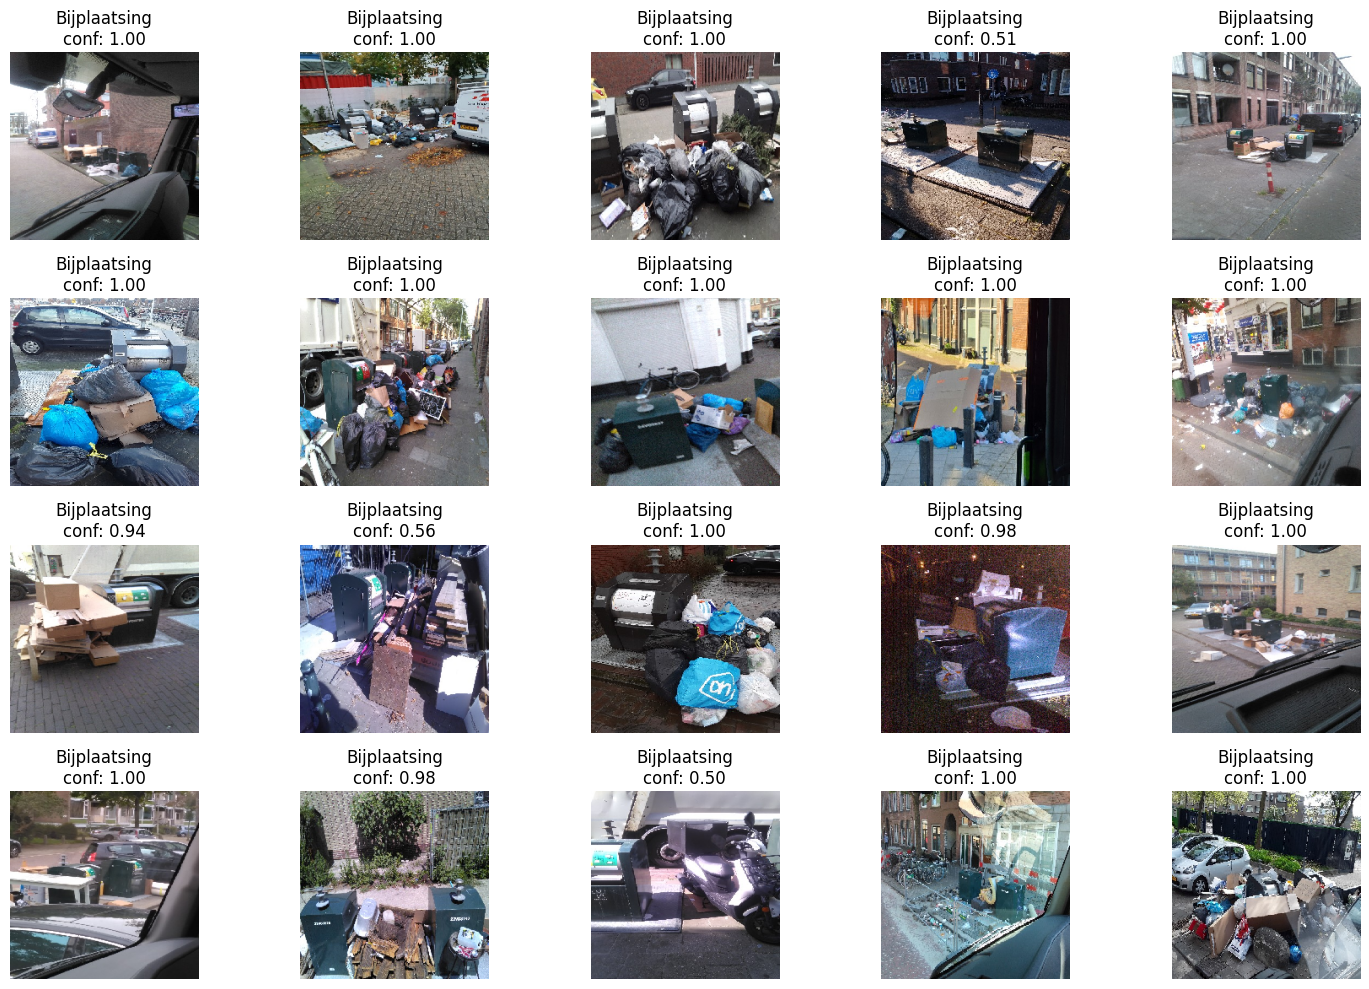

In [12]:
# Visualisatie fixed
fig = plt.figure(figsize=(15, 10))

for idx, rel_path in enumerate(sample):

   
    if rel_path.startswith("routeeventlog"):
        img_path = os.path.join("C:/ai-semester", rel_path)
    
    if not os.path.exists(img_path):
        print(f"Niet gevonden: {img_path}")
        continue

    result = model.predict(img_path, verbose=False)[0]
    conf = float(result.probs.top1conf)
    img = image.load_img(img_path, target_size=(224, 224))

    ax = fig.add_subplot(4, 5, idx + 1)
    ax.imshow(img)
    ax.set_title(f"Bijplaatsing\nconf: {conf:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()


Hierboven een mooi aantal foto's te zien met bijplaatsing, bij de foto's waar hij conf: 1 heeft is ook echt duidelijk bijplaatsing te zien. De foto's met een minder hoge zekerheid heeft is dit ook terecht.

# Duplicates verwijderen met image hashing

Er zitten in de dataset nog foto's die hetzelfde zijn maar er meerdere keren in staan. Deze duplicaten willen we vinden, beoordelen en handmatig verwijderen. Ik heb hier een tool voor gevonden 'perceptual hashing'. Deze tool detecteert identieke afbeeldingen, ongeacht bestandsnaam.

In [13]:
#imports
from PIL import Image
import imagehash
from tqdm import tqdm

#path
duplicates_output = r"C:\Users\rtvan\Documents\GitHub\AI-Waste_Vision_POC\Bijplaatsing Detection\Yolov8\duplicates_found.txt"


In [14]:
# Lees alle relative paths
with open(output_txt, "r") as f:
    rel_paths = [line.strip() for line in f.readlines()]

# Zet alles direct om naar absolute paths
absolute_paths = [os.path.join("C:/ai-semester", rel_path) for rel_path in rel_paths]

print(f"Totaal afbeeldingen voor duplicate check: {len(absolute_paths)}")

#Duplicate detection met perceptual hashing
hash_map = {}      # hash → eerste file
duplicates = []    # gevonden duplicates

for img_path in tqdm(absolute_paths):
    try:
        img = Image.open(img_path)
        img_hash = imagehash.phash(img)

        if img_hash in hash_map:
            duplicates.append(img_path)
        else:
            hash_map[img_hash] = img_path

    except Exception as e:
        print(f"Fout bij openen: {img_path}", e)

print("\nKlaar!")
print(f"Totaal duplicates gevonden: {len(duplicates)}")

# Schrijf duplicates naar TXT
with open(duplicates_output, "w") as f:
    f.writelines(path + "\n" for path in duplicates)

print(f"Duplicates opgeslagen in: {duplicates_output}")

Totaal afbeeldingen voor duplicate check: 13114


100%|██████████| 13114/13114 [00:40<00:00, 324.39it/s]


Klaar!
Totaal duplicates gevonden: 1802
Duplicates opgeslagen in: C:\Users\rtvan\Documents\GitHub\AI-Waste_Vision_POC\Bijplaatsing Detection\Yolov8\duplicates_found.txt


1802 foto's die hetzelfde zijn, best veel

Aantal clusters met duplicaten: 15


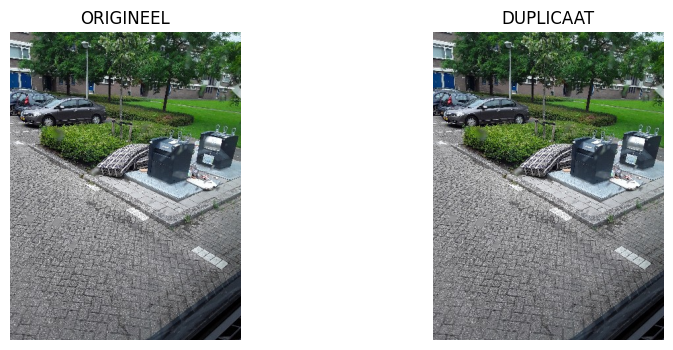

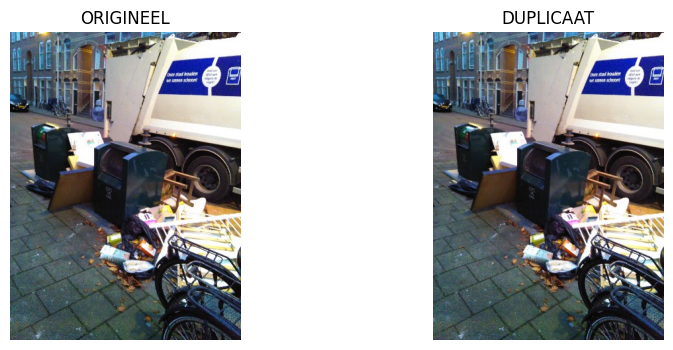

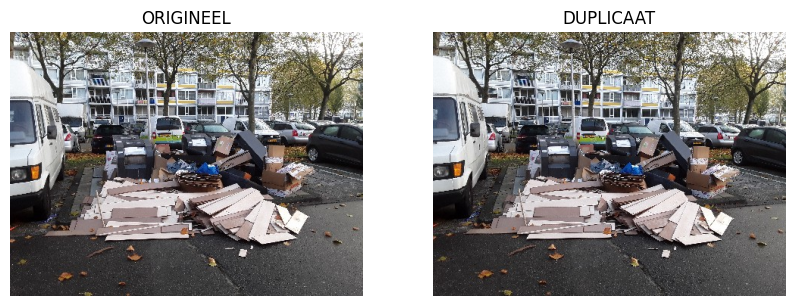

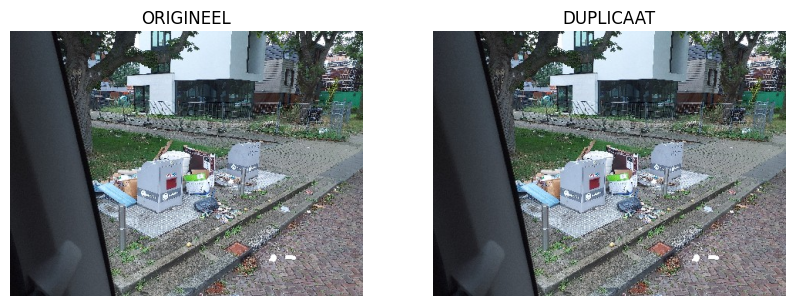

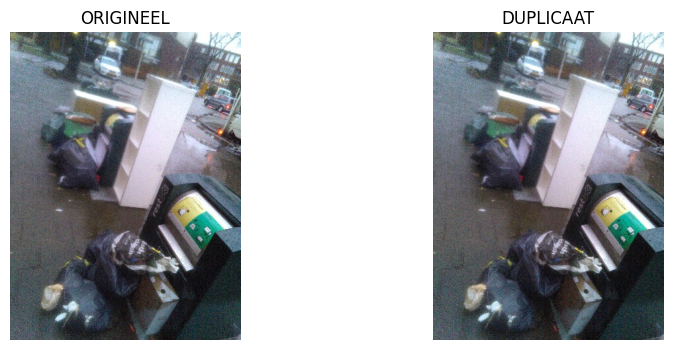

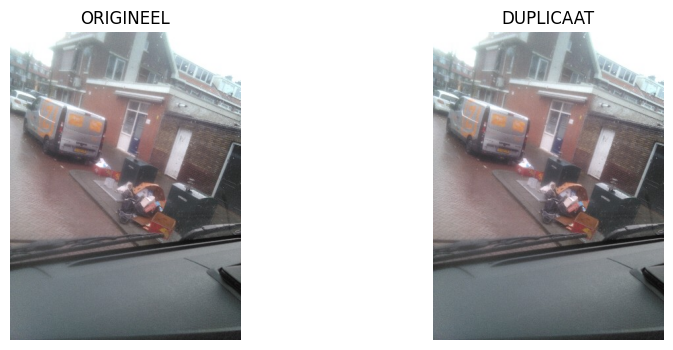

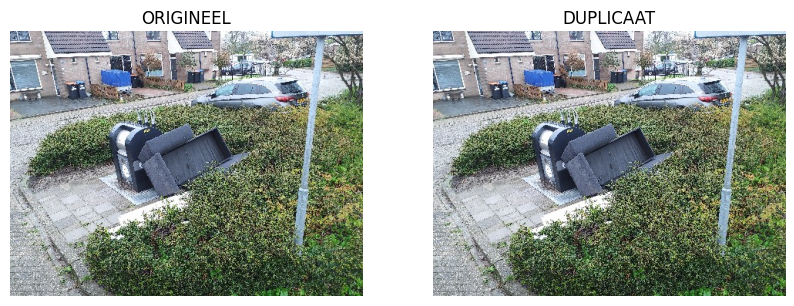

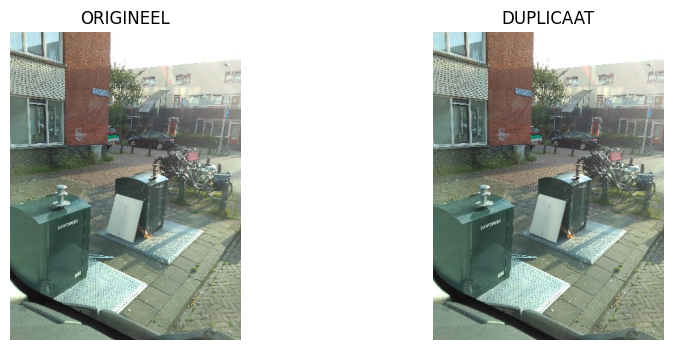

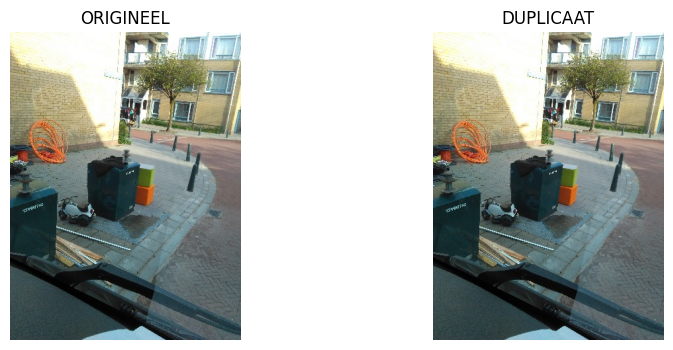

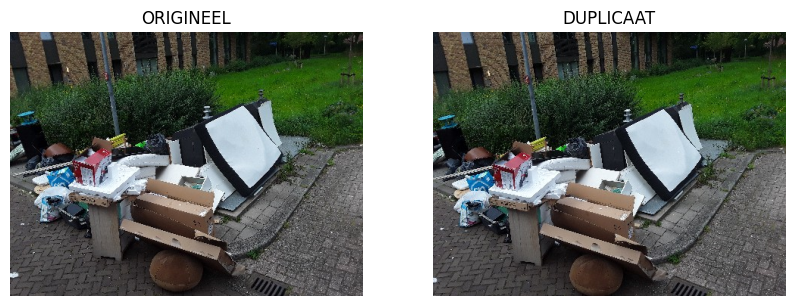

In [17]:
# %%
import matplotlib.pyplot as plt
from PIL import Image

# Maak clusters: zelfde hash = zelfde visuele afbeelding
clusters = {}

for img_path in absolute_paths:
    try:
        img = Image.open(img_path)
        img_hash = imagehash.phash(img)

        if img_hash not in clusters:
            clusters[img_hash] = [img_path]  # origineel
        else:
            clusters[img_hash].append(img_path)  # duplicate
    except:
        continue


# Visualiseer 10 cluster-pairs zonder paden
N = 10

for i, paths in enumerate(duplicate_clusters[:N]):
    original = paths[0]
    duplicate = paths[1]   # eerste duplicaat

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(Image.open(original))
    axes[0].set_title("ORIGINEEL")
    axes[0].axis("off")

    axes[1].imshow(Image.open(duplicate))
    axes[1].set_title("DUPLICAAT")
    axes[1].axis("off")

    plt.show()


Hierboven een aantal foto's ter controle die dus inderdaad precies hetzelde zijn en er dus vaker in staan.

In [18]:
duplicate_clusters = [paths for paths in clusters.values() if len(paths) > 1]
print(f"Aantal clusters met duplicaten: {len(duplicate_clusters)}")

Aantal clusters met duplicaten: 15


In [21]:
# Analyse: hoeveel duplicaten per cluster?
cluster_sizes = []
print("\nDuplicaten per cluster:")

for i, paths in enumerate(duplicate_clusters, start=1):
    cluster_size = len(paths) - 1  # aantal duplicaten, exclusief origineel
    cluster_sizes.append(cluster_size)
    print(f"Cluster {i}: {cluster_size} duplicaten")



Duplicaten per cluster:
Cluster 1: 1 duplicaten
Cluster 2: 1 duplicaten
Cluster 3: 1 duplicaten
Cluster 4: 194 duplicaten
Cluster 5: 1 duplicaten
Cluster 6: 1 duplicaten
Cluster 7: 747 duplicaten
Cluster 8: 1 duplicaten
Cluster 9: 1 duplicaten
Cluster 10: 1 duplicaten
Cluster 11: 1 duplicaten
Cluster 12: 2 duplicaten
Cluster 13: 723 duplicaten
Cluster 14: 63 duplicaten
Cluster 15: 64 duplicaten


De duplicaten komen bijna volledig door 3 clusters: Cluster 7 = 747 duplicaten, Cluster 13 = 723 duplicaten en Cluster 4 = 194 duplicaten

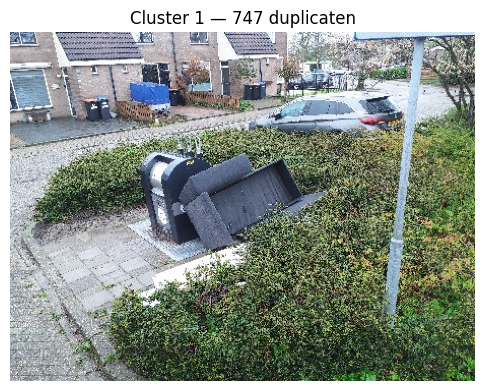

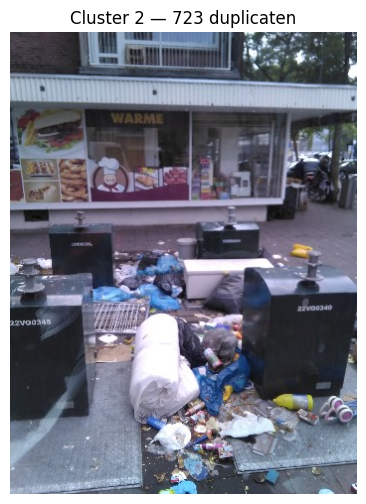

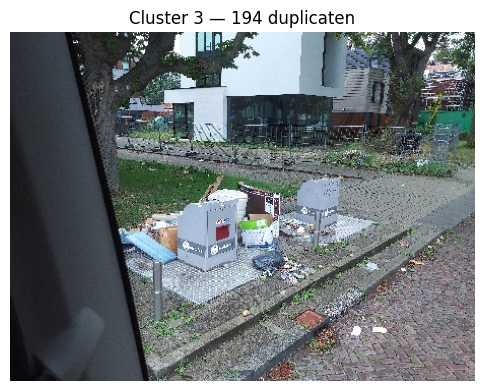

In [24]:
# Bereken duplicaat-aantallen per cluster: (dup_count, original_path)
info = [(len(paths)-1, paths[0]) for paths in duplicate_clusters]

# Sorteer en kies top 3
top3 = sorted(info, reverse=True)[:3]

# Toon foto's
for i, (count, path) in enumerate(top3, 1):
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(path))
    plt.title(f"Cluster {i} — {count} duplicaten")
    plt.axis("off")
    plt.show()


Waarschijnlijk zijn dit duplicaten die ergens in hun systeem honderden keren gedupliceerd zijn. In totaal vormen deze drie beelden ruim 90% van alle gevonden duplicaten. Waarschijnlijk gaat het om een of meerdere incidentmeldingen die ergens in de keten herhaaldelijk opnieuw verwerkt of opgeslagen zijn. Door deze duplicaten te verwijderen houden we een schone dataset over voor verdere modeltraining.


### Duplicates verwijderen

In [25]:
removed = 0

for paths in duplicate_clusters:
    duplicates_to_remove = paths[1:]   # paths[0] = origineel, niet verwijderen

    for dup in duplicates_to_remove:
        try:
            os.remove(dup)
            removed += 1
        except Exception as e:
            print(f"Kon niet verwijderen: {dup} ({e})")

print(f"\nKlaar! {removed} duplicaten verwijderd.")



Klaar! 1802 duplicaten verwijderd.


In [27]:
# Nieuwe TXT zonder duplicaten
clean_output_txt = r"C:\Users\rtvan\Documents\GitHub\AI-Waste_Vision_POC\Bijplaatsing Detection\Yolov8\bijplaatsing_images_clean.txt"

with open(output_txt, "r") as f:
    rel_paths = [line.strip() for line in f.readlines()]

clean_paths = []

for rel_path in rel_paths:
    abs_path = os.path.join("C:/ai-semester", rel_path)

    if os.path.exists(abs_path):      # alleen behouden als foto fysiek nog bestaat
        clean_paths.append(rel_path)

with open(clean_output_txt, "w") as f:
    f.writelines(p + "\n" for p in clean_paths)

print(f"Aantal unieke foto's na opschonen: {len(clean_paths)}")


Aantal unieke foto's na opschonen: 11312
